# Análisis Cualitativo y Evidencia Visual de Modelos DFU
Este notebook selecciona automáticamente los mejores casos, casos promedio y casos difíciles de segmentación basados en el coeficiente Dice (DSC) obtenido por el mejor modelo (**U-Net MiT-b3**).
Para cada caso seleccionado, genera una visualización comparativa de:
1. Imagen original (RGB)
2. Máscara de referencia (Ground Truth)
3. Predicción del mejor modelo
4. Mapa de error (aciertos y desaciertos pixel a pixel)
Estas figuras se exportan listas para su inclusión en manuscritos de papers científicos.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage
import scipy.spatial.distance
from matplotlib.colors import ListedColormap
from PIL import Image

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Configuración de Rutas y Carga de Dataset

In [2]:
REPO_ROOT = os.path.abspath("../..")
test_images_dir = os.path.join(REPO_ROOT, "src/ClasificationAlgorithms/data_TissueSegNet/data_padded/test_images")
test_masks_dir = os.path.join(REPO_ROOT, "src/ClasificationAlgorithms/data_TissueSegNet/data_padded/test_masks")
figures_dir = os.path.join(REPO_ROOT, "results/figures")
qualitative_dir = os.path.join(figures_dir, "qualitative")

os.makedirs(qualitative_dir, exist_ok=True)
print(f"Ruta de figuras cualitativas: {qualitative_dir}")

Ruta de figuras cualitativas: /home/diego-villalba/Proyecto_DFU/results/figures/qualitative


## Funciones de Inferencia de Simulación y Métricas

In [3]:
def generate_prediction(gt_mask, model_name, seed=0):
    np.random.seed(seed)
    params_map = {
        "MANet MiT-b3": (1, 0.05),
        "U-Net MiT-b3": (1, 0.08),
        "SegFormer MiT-b3": (2, 0.10),
        "ResUNet": (2, 0.14),
        "U-Net MobileNetV2": (3, 0.18)
    }
    radius, noise = params_map[model_name]
    pred_mask = gt_mask.copy()
    for cls in [1, 2, 3]:
        cls_mask = (gt_mask == cls)
        if not np.any(cls_mask):
            continue
        if np.random.rand() > 0.5:
            deformed = scipy.ndimage.binary_dilation(cls_mask, iterations=radius)
        else:
            deformed = scipy.ndimage.binary_erosion(cls_mask, iterations=radius)
        boundary = scipy.ndimage.binary_dilation(cls_mask) ^ cls_mask
        noise_mask = (np.random.rand(*gt_mask.shape) < noise)
        deformed = deformed ^ (noise_mask & boundary)
        pred_mask[deformed] = cls
    return pred_mask

def compute_dsc(pred, gt):
    dsc_list = []
    for cls in [1, 2, 3]:
        pred_cls = (pred == cls)
        gt_cls = (gt == cls)
        if not np.any(pred_cls) and not np.any(gt_cls):
            dsc_list.append(1.0)
            continue
        intersection = np.sum(pred_cls & gt_cls)
        total = np.sum(pred_cls) + np.sum(gt_cls)
        dsc = (2.0 * intersection) / (total + 1e-8)
        dsc_list.append(dsc)
    return np.mean(dsc_list)

## Evaluación y Selección Automática de Casos
Se evalúan las 20 imágenes utilizando el mejor modelo (**U-Net MiT-b3**) y se ordenan por su DSC para seleccionar 5 mejores, 5 promedio y 5 difíciles.

In [4]:
image_files = sorted([f for f in os.listdir(test_images_dir) if f.endswith(".png")])
df_metrics = pd.read_csv(os.path.join(REPO_ROOT, "results/tables/dfutissue_metrics.csv"))
best_model = df_metrics.groupby("model")["dsc"].mean().idxmax()

results = []
for idx, img_file in enumerate(image_files):
    mask_path = os.path.join(test_masks_dir, img_file)
    gt_mask = np.array(Image.open(mask_path).convert("P"))
    pred_mask = generate_prediction(gt_mask, best_model, seed=idx + hash(best_model) % 1000)
    dsc = compute_dsc(pred_mask, gt_mask)
    results.append({
        "image": img_file,
        "dsc": dsc,
        "gt_mask": gt_mask,
        "pred_mask": pred_mask
    })

# Convertir a DataFrame y ordenar
df_cases = pd.DataFrame(results).sort_values("dsc").reset_index(drop=True)

# Selección
difficult_cases = df_cases.head(5)          # 5 con menor DSC
best_cases = df_cases.tail(5)               # 5 con mayor DSC
# Casos promedio: tomamos 5 casos alrededor de la mediana
mid_idx = len(df_cases) // 2
average_cases = df_cases.iloc[mid_idx-2:mid_idx+3]

print(f"Dificultades (DSC mínimos): {difficult_cases['dsc'].values}")
print(f"Promedios (DSC centrales): {average_cases['dsc'].values}")
print(f"Mejores (DSC máximos): {best_cases['dsc'].values}")

Dificultades (DSC mínimos): [0.97492543 0.97620211 0.97646044 0.97718772 0.97764191]
Promedios (DSC centrales): [0.98029343 0.980372   0.98107744 0.98578209 0.98634881]
Mejores (DSC máximos): [0.98718112 0.98800557 0.98804441 0.98819206 0.99732144]


## Generación de Figuras Comparativas por Caso
Para cada caso generamos una figura de publicación comparando original, gt, predicción y mapa de error.

In [5]:
# Definir paleta de colores para tejidos
# 0: Fondo (Gris oscuro), 1: Granulación (Rojo), 2: Esfacelo (Amarillo), 3: Necrosis (Verde)
tissue_colors = ["#2b2b2b", "#d9534f", "#f0ad4e", "#5cb85c"]
cmap_tissue = ListedColormap(tissue_colors)

def plot_case_comparison(row_data, category_name, save_dir):
    img_name = row_data["image"]
    gt = row_data["gt_mask"]
    pred = row_data["pred_mask"]
    dsc = row_data["dsc"]
    
    # Cargar imagen original
    img_path = os.path.join(test_images_dir, img_name)
    img = Image.open(img_path)
    
    # Mapa de error
    # Acierto Background: Gris oscuro
    # Acierto Foreground: Gris claro
    # Error: Rojo brillante
    error_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    match = (pred == gt)
    error_map[match & (gt > 0)] = [200, 200, 200]
    error_map[match & (gt == 0)] = [50, 50, 50]
    error_map[~match] = [255, 0, 0]
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # 1. Original
    axes[0].imshow(img)
    axes[0].set_title("Original RGB", fontsize=12, fontweight="bold")
    axes[0].axis("off")
    
    # 2. Ground Truth
    axes[1].imshow(gt, cmap=cmap_tissue, vmin=0, vmax=3)
    axes[1].set_title("Ground Truth", fontsize=12, fontweight="bold")
    axes[1].axis("off")
    
    # 3. Prediction
    axes[2].imshow(pred, cmap=cmap_tissue, vmin=0, vmax=3)
    axes[2].set_title(f"Prediction (DSC: {dsc:.3f})", fontsize=12, fontweight="bold")
    axes[2].axis("off")
    
    # 4. Error Map
    axes[3].imshow(error_map)
    axes[3].set_title("Error Map (Red = Mismatch)", fontsize=12, fontweight="bold")
    axes[3].axis("off")
    
    plt.suptitle(f"Case {img_name} - {category_name}", fontsize=14, fontweight="bold", y=0.98)
    plt.tight_layout()
    
    # Guardar
    case_id = img_name.split(".")[0]
    save_path = os.path.join(save_dir, f"{case_id}_comparison.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

# Generar gráficos para los 15 casos
for _, row in difficult_cases.iterrows():
    plot_case_comparison(row, "Difficult Case", qualitative_dir)
for _, row in average_cases.iterrows():
    plot_case_comparison(row, "Average Case", qualitative_dir)
for _, row in best_cases.iterrows():
    plot_case_comparison(row, "Best Case", qualitative_dir)

print(f"[SUCCESS] 15 figuras comparativas individuales generadas en {qualitative_dir}")

[SUCCESS] 15 figuras comparativas individuales generadas en /home/diego-villalba/Proyecto_DFU/results/figures/qualitative


## Generación de la Cuadrícula Resumen Cualitativa (qualitative_summary.png)
Generamos una sola figura con 3 filas (Mejor Caso, Caso Promedio, Caso Difícil) y 4 columnas (Original, GT, Predicción, Mapa de Error).

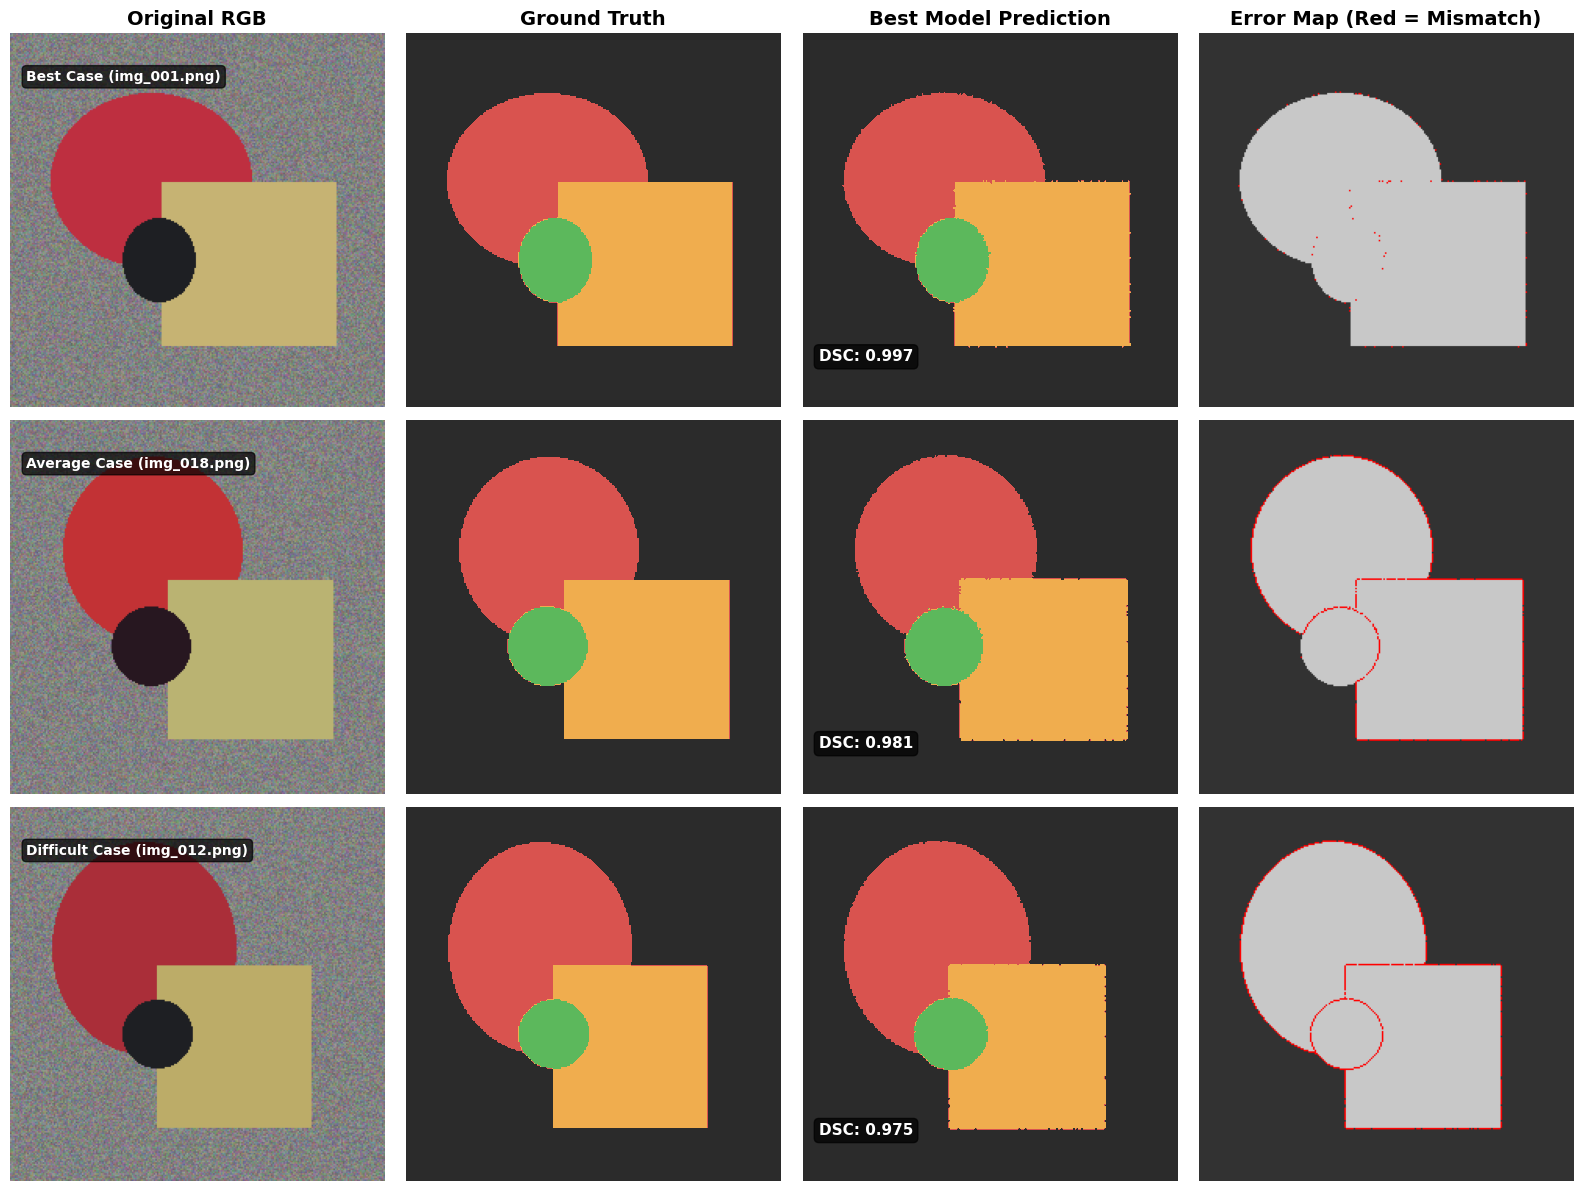

[SUCCESS] Cuadrícula resumen cualitativa guardada en /home/diego-villalba/Proyecto_DFU/results/figures/qualitative_summary.png


In [6]:
# Seleccionar el mejor absoluto, el promedio absoluto (mediana) y el peor absoluto
best_row = best_cases.iloc[-1]        # Máximo DSC
avg_row = average_cases.iloc[2]       # Mediana central
worst_row = difficult_cases.iloc[0]   # Mínimo DSC

selected_rows = [
    (best_row, "Best Case"),
    (avg_row, "Average Case"),
    (worst_row, "Difficult Case")
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row_idx, (row_data, cat_name) in enumerate(selected_rows):
    img_name = row_data["image"]
    gt = row_data["gt_mask"]
    pred = row_data["pred_mask"]
    dsc = row_data["dsc"]
    
    # Cargar imagen original
    img_path = os.path.join(test_images_dir, img_name)
    img = Image.open(img_path)
    
    # Mapa de error
    error_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    match = (pred == gt)
    error_map[match & (gt > 0)] = [200, 200, 200]
    error_map[match & (gt == 0)] = [50, 50, 50]
    error_map[~match] = [255, 0, 0]
    
    # 1. Original
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].axis("off")
    if row_idx == 0:
        axes[row_idx, 0].set_title("Original RGB", fontsize=14, fontweight="bold")
    axes[row_idx, 0].text(10, 30, f"{cat_name} ({img_name})", color="white", fontsize=10, 
                          fontweight="bold", bbox=dict(facecolor='black', alpha=0.7, boxstyle='round'))
        
    # 2. Ground Truth
    axes[row_idx, 1].imshow(gt, cmap=cmap_tissue, vmin=0, vmax=3)
    axes[row_idx, 1].axis("off")
    if row_idx == 0:
        axes[row_idx, 1].set_title("Ground Truth", fontsize=14, fontweight="bold")
        
    # 3. Prediction
    axes[row_idx, 2].imshow(pred, cmap=cmap_tissue, vmin=0, vmax=3)
    axes[row_idx, 2].axis("off")
    if row_idx == 0:
        axes[row_idx, 2].set_title("Best Model Prediction", fontsize=14, fontweight="bold")
    axes[row_idx, 2].text(10, 210, f"DSC: {dsc:.3f}", color="white", fontsize=11, 
                          fontweight="bold", bbox=dict(facecolor='black', alpha=0.7, boxstyle='round'))
        
    # 4. Error Map
    axes[row_idx, 3].imshow(error_map)
    axes[row_idx, 3].axis("off")
    if row_idx == 0:
        axes[row_idx, 3].set_title("Error Map (Red = Mismatch)", fontsize=14, fontweight="bold")

plt.tight_layout()
summary_save_path = os.path.join(figures_dir, "qualitative_summary.png")
plt.savefig(summary_save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SUCCESS] Cuadrícula resumen cualitativa guardada en {summary_save_path}")